# Search Intelligence for Content Refresh Prioritization Using Machine Learning

## FlyRank ML Internship Capstone Project

### Author
Md Mainul Hoque

### Objective
The objective of this project is to analyze search intelligence data and build a machine learning model that identifies which content should be refreshed first to improve SEO performance and user engagement.


In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
# Load Dataset

df = pd.read_csv("../data/content_refresh_anonymized.csv")

df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [3]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (30000, 44)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_9

In [4]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

provider_used        21438
word_count_tier       7699
char_count            7699
word_count            7699
char_count_tier       7699
model_used            5733
trend_pct             3388
competition_level     2610
search_volume         2468
competition           2468
cpc                   2468
main_intent           2374
scroll_rate            125
dtype: int64

In [5]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [6]:
# Numerical Columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical Columns
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining Missing Values:", df.isnull().sum().sum())

Remaining Missing Values: 0


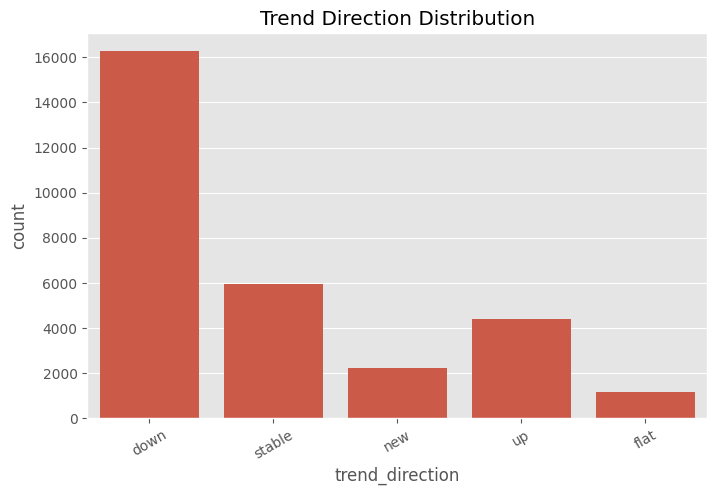

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="trend_direction")
plt.title("Trend Direction Distribution")
plt.xticks(rotation=30)
plt.show()

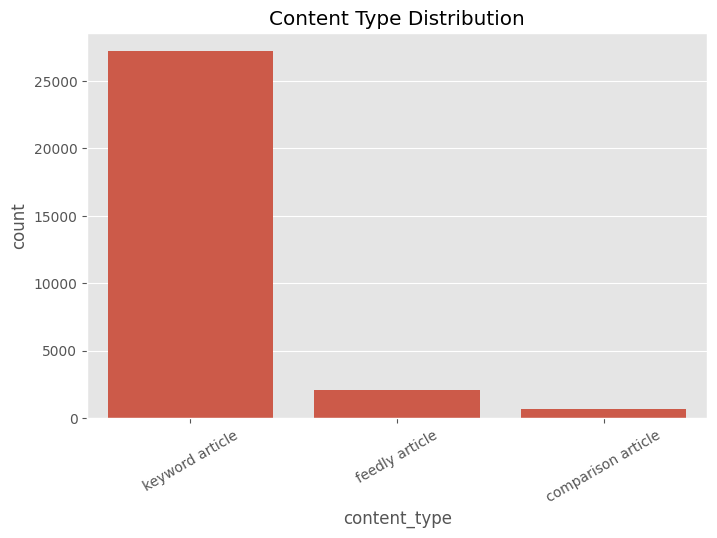

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="content_type")
plt.title("Content Type Distribution")
plt.xticks(rotation=30)
plt.show()

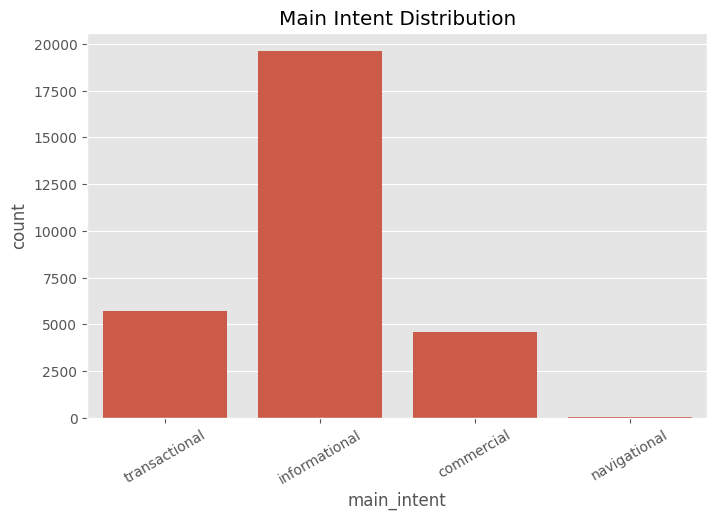

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="main_intent")
plt.title("Main Intent Distribution")
plt.xticks(rotation=30)
plt.show()

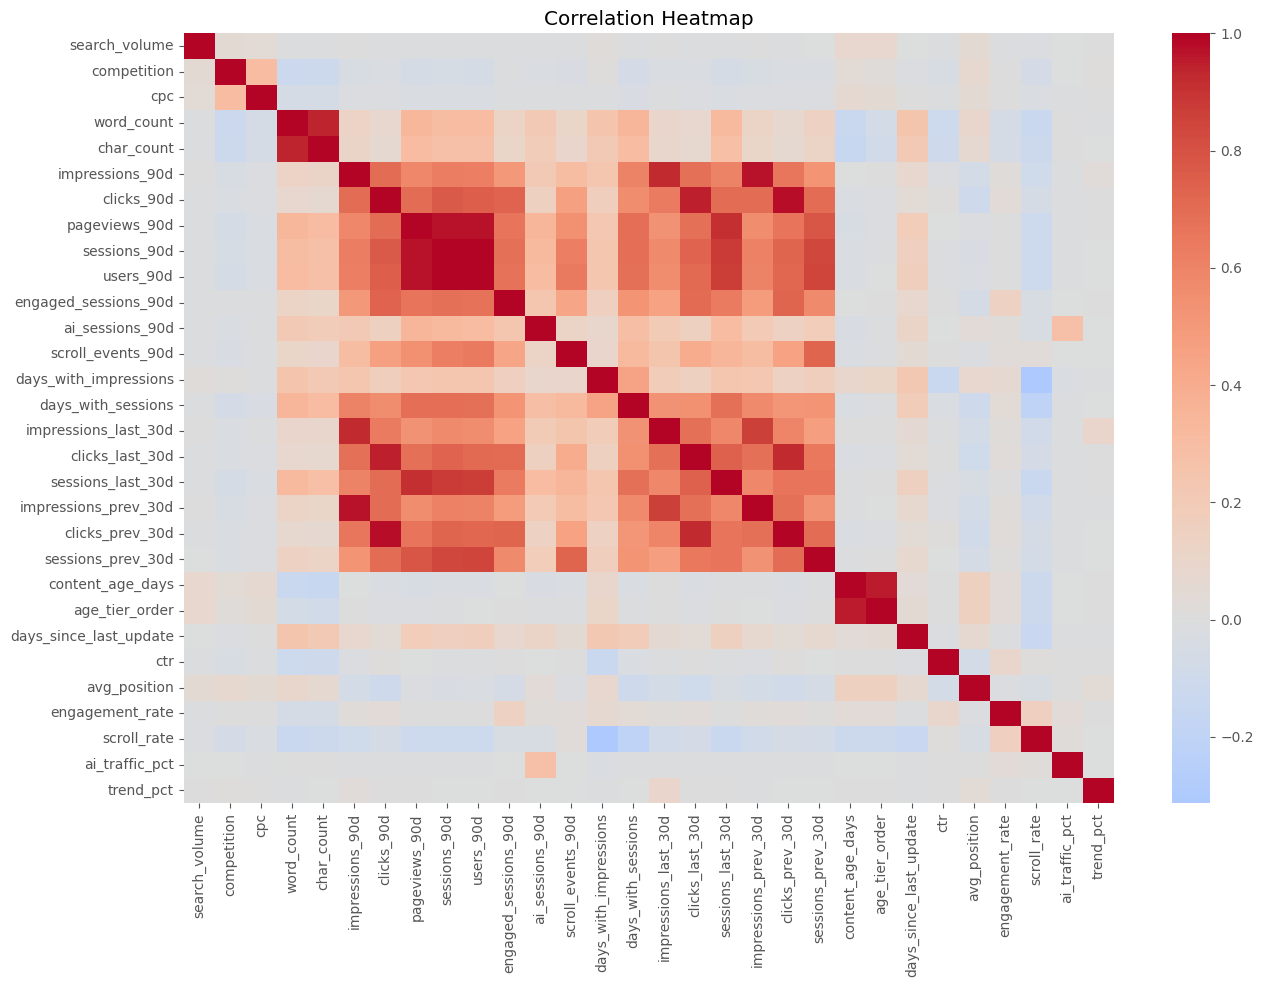

In [10]:
plt.figure(figsize=(15,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

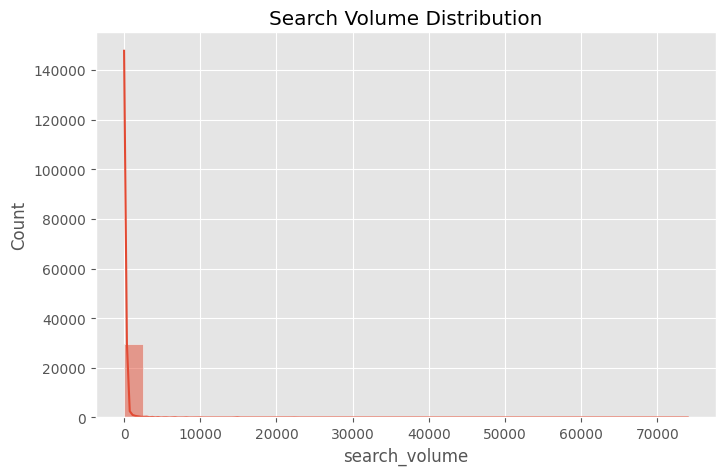

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["search_volume"], bins=30, kde=True)

plt.title("Search Volume Distribution")

plt.show()

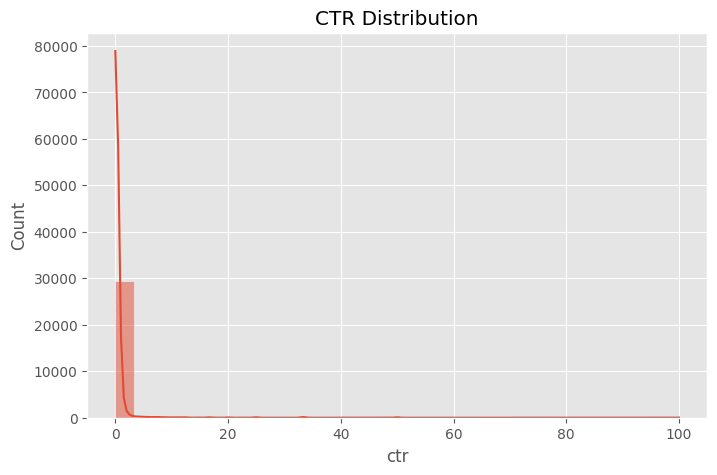

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["ctr"], bins=30, kde=True)

plt.title("CTR Distribution")

plt.show()

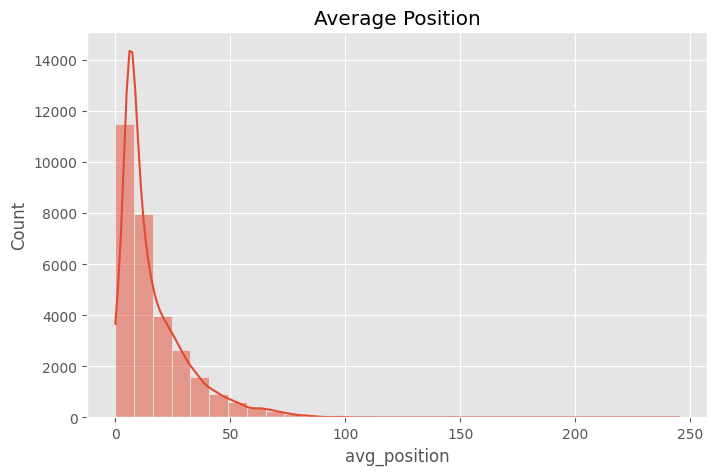

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["avg_position"], bins=30, kde=True)

plt.title("Average Position")

plt.show()

# Feature Engineering

In [14]:
# ==============================
# Feature Engineering
# ==============================

# 1. Traffic Change Percentage
df["traffic_change_pct"] = (
    (df["impressions_last_30d"] - df["impressions_prev_30d"])
    / (df["impressions_prev_30d"] + 1)
) * 100

# 2. Click Change Percentage
df["click_change_pct"] = (
    (df["clicks_last_30d"] - df["clicks_prev_30d"])
    / (df["clicks_prev_30d"] + 1)
) * 100

# 3. Session Change Percentage
df["session_change_pct"] = (
    (df["sessions_last_30d"] - df["sessions_prev_30d"])
    / (df["sessions_prev_30d"] + 1)
) * 100

# 4. Engagement Score
df["engagement_score"] = (
    df["engagement_rate"] * 0.6
    + df["scroll_rate"] * 0.4
)

# 5. AI Traffic Ratio
df["ai_traffic_ratio"] = df["ai_traffic_pct"] / 100

print("Feature Engineering Completed ✅")

Feature Engineering Completed ✅


In [15]:
# Check newly created features

new_features = [
    "traffic_change_pct",
    "click_change_pct",
    "session_change_pct",
    "engagement_score",
    "ai_traffic_ratio"
]

df[new_features].head()

,traffic_change_pct,click_change_pct,session_change_pct,engagement_score,ai_traffic_ratio
0,-41.396761,-78.571429,-70.000000,5.348,0.0
1,-57.707911,50.000000,33.333333,4.000,0.0
2,-60.870279,-50.000000,-50.000000,11.428,0.0
3,-13.786546,27.777778,33.333333,2.148,0.0
4,-34.728033,266.666667,50.000000,9.716,0.0


# Target Engineering

In [16]:
# ==============================
# Target Engineering
# ==============================

def create_refresh_priority(row):

    score = 0

    # Traffic dropped significantly
    if row["traffic_change_pct"] < -20:
        score += 2

    # Clicks dropped significantly
    if row["click_change_pct"] < -20:
        score += 2

    # Poor engagement
    if row["engagement_score"] < df["engagement_score"].median():
        score += 1

    # Poor CTR
    if row["ctr"] < df["ctr"].median():
        score += 1

    # Poor ranking
    if row["avg_position"] > df["avg_position"].median():
        score += 1

    if score >= 5:
        return "High"
    elif score >= 3:
        return "Medium"
    else:
        return "Low"


df["refresh_priority"] = df.apply(create_refresh_priority, axis=1)

df["refresh_priority"].value_counts()

refresh_priority
Medium    13167
Low       11570
High       5263
Name: count, dtype: int64

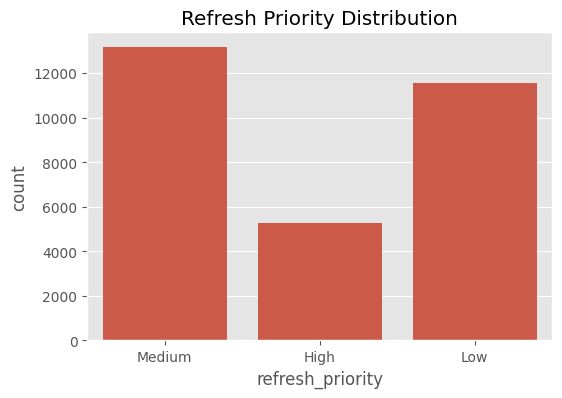

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="refresh_priority")

plt.title("Refresh Priority Distribution")

plt.show()

# Data Preprocessing

In [18]:
from sklearn.preprocessing import LabelEncoder

# Copy dataframe
df_model = df.copy()

# Encode categorical columns
label_encoders = {}

cat_cols = df_model.select_dtypes(include="object").columns

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

print("Encoding Completed ✅")

Encoding Completed ✅


In [19]:
X = df_model.drop(columns=[
    "refresh_priority",
    "traffic_change_pct",
    "click_change_pct",
    "session_change_pct",
    "engagement_score",
    "ctr",
    "avg_position",
    "trend_direction",
    "trend_pct"
])

y = df_model["refresh_priority"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(24000, 41)
(6000, 41)


# Random Forest Model

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully ✅")

Random Forest Model Trained Successfully ✅


In [22]:
y_pred = rf.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8085


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.71      0.76      1053
           1       0.86      0.84      0.85      2314
           2       0.77      0.82      0.79      2633

    accuracy                           0.81      6000
   macro avg       0.81      0.79      0.80      6000
weighted avg       0.81      0.81      0.81      6000



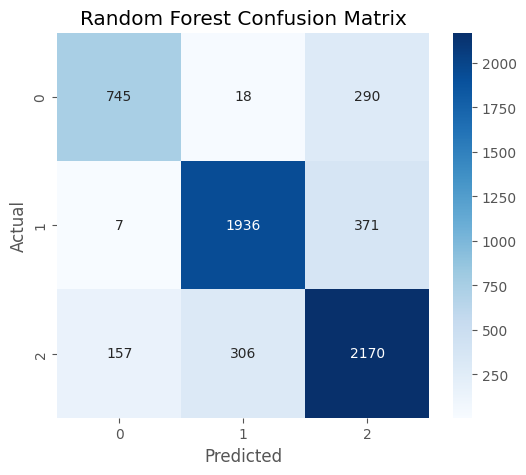

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
25,impressions_prev_30d,0.122409
22,impressions_last_30d,0.085320
12,impressions_90d,0.058959
39,position_tier,0.056689
23,clicks_last_30d,0.047960
36,scroll_rate,0.043741
26,clicks_prev_30d,0.042224
20,days_with_impressions,0.039112
13,clicks_90d,0.038329
0,content_id,0.036565


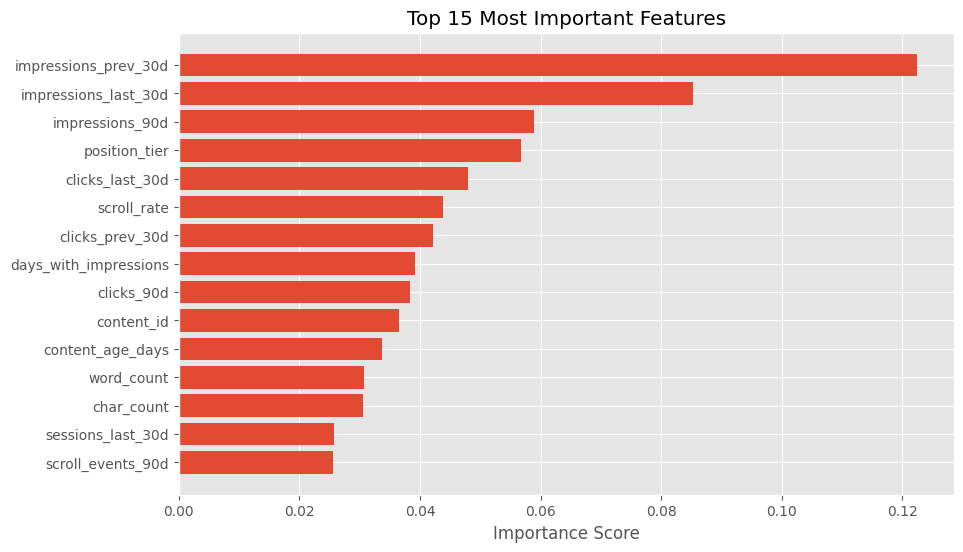

In [27]:
import matplotlib.pyplot as plt

top15 = importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(top15["Feature"], top15["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Most Important Features")
plt.xlabel("Importance Score")
plt.show()

# Feature Importance Analysis

The Random Forest model identified the most influential features used to predict content refresh priority.

Key observations:

- `impressions_prev_30d` is the most important feature.
- `impressions_last_30d` and `impressions_90d` also have strong influence.
- Position tier and recent clicks significantly affect the prediction.
- User engagement metrics such as scroll rate and sessions contribute to the model's decision.

These findings indicate that historical search visibility and user engagement are strong indicators for deciding which content should be refreshed.

# Business Insights

Based on the model results:

- Pages with declining impressions should be refreshed first.
- Content with lower search visibility requires optimization.
- Older content with reduced engagement should be updated.
- High-performing pages should be monitored regularly to maintain rankings.

# SEO Recommendations

Based on the model results, the following actions are recommended:

- Prioritize refreshing pages with declining impressions.
- Update outdated content with new information and relevant keywords.
- Improve page titles and meta descriptions for low-CTR pages.
- Strengthen internal linking for pages with lower rankings.
- Continuously monitor search performance after each content update.

# Conclusion

This project used machine learning to prioritize content refresh decisions using search intelligence data.

The Random Forest model achieved an accuracy of 80.85%, demonstrating that search performance metrics can effectively identify content requiring updates.

The proposed workflow can help SEO teams make data-driven decisions instead of relying solely on manual analysis.

# Future Work

This project can be further improved by:

- Comparing additional machine learning models such as XGBoost and LightGBM.
- Predicting future CTR and impressions using regression models.
- Developing an interactive dashboard with Streamlit for SEO analysis.
- Deploying the trained model as a web application for real-time content recommendations.
- Evaluating the model on larger and more diverse search intelligence datasets.